# CatBoost Optimization — Used Car Dynamic Pricing

This notebook trains a **CatBoostRegressor** on the processed feature engineering dataset and compares it against the existing XGBoost baseline.

**Input:** `data/processed/train_fe.csv`  
**Model output:** `models/catboost_model.cbm`  
**Prediction output:** `outputs/catboost_validation_predictions.csv`

CatBoost is a strong choice here because the dataset contains many categorical or discrete business fields such as `brand`, `model`, `bodyType`, `fuelType`, `gearbox`, `regionCode`, and engineered bins.

## Setup

Load libraries, define project paths, and create output directories.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "train_fe.csv"
XGB_PRED_PATH = PROJECT_ROOT / "outputs" / "xgb_validation_predictions.csv"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CATBOOST_MODEL_PATH = MODEL_DIR / "catboost_model.cbm"
CATBOOST_PRED_PATH = OUTPUT_DIR / "catboost_validation_predictions.csv"

TEST_SIZE = 0.2
RANDOM_STATE = 42
EARLY_STOPPING_ROUNDS = 50

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 150

## 1. Load Processed Dataset

The input dataset is the output from feature engineering. It includes original fields, engineered date/business features, aggregation features, and anonymous `v_*` features.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (150000, 49)


,SaleID,name,regDate,model,brand,bodyType,fuelType,gearbox,power,kilometer,...,km_per_year,power_bin,car_age_bin,brand_price_mean,brand_price_median,brand_price_std,brand_price_max,model_power_mean,model_power_std,model_count
0,0,736,20040402,30.0,6,1.0,0.0,0.0,60,12.5,...,1.041192,p0_60,a12_20,3611.840266,1800.0,4681.293524,59900,64.700256,31.990438,2342.0
1,1,2262,20030301,40.0,1,2.0,0.0,0.0,0,15.0,...,1.151724,p0_60,a12_20,9273.311947,6499.0,9369.631497,99900,140.859396,52.495875,4502.0
2,2,14874,20040403,115.0,15,1.0,0.0,0.0,163,12.5,...,1.041904,p140_200,a8_12,9858.582990,8500.0,5425.058140,45000,137.343042,40.963832,927.0
3,3,71865,19960908,109.0,10,0.0,0.0,1.0,193,15.0,...,0.768947,p140_200,a12_20,8470.804197,5400.0,8988.307535,98000,259.880829,102.059068,386.0
4,4,111080,20120103,110.0,5,1.0,0.0,0.0,68,5.0,...,1.192848,p60_100,a3_5,3306.349411,2300.0,3343.624586,31500,57.186004,23.085682,543.0


## 2–3. Define Features and Target

`price` is the target. `SaleID` is an identifier and must not be used as a model feature.

Feature columns are created by removing:
- `SaleID`
- `price`

In [3]:
TARGET = "price"
ID_COL = "SaleID"

sale_ids = df[ID_COL]
y = df[TARGET]
X = df.drop(columns=[ID_COL, TARGET])

print(f"Target: {TARGET}")
print(f"Feature shape: {X.shape}")

Target: price
Feature shape: (150000, 47)


## 4. Train / Validation Split

Use the same split configuration as the XGBoost baseline:

- `test_size=0.2`
- `random_state=42`

Keeping the same split makes the validation MAE comparison fair.

In [4]:
X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
    X,
    y,
    sale_ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"Train rows: {X_train.shape[0]:,}")
print(f"Validation rows: {X_val.shape[0]:,}")

Train rows: 120,000
Validation rows: 30,000


## 5. Automatically Identify Categorical Columns

CatBoost can consume categorical features directly. We identify them using two signals:

1. Columns with text/category dtype, such as date strings and engineered bins.
2. Known business categorical fields that are numerically encoded in the dataset, such as `brand`, `model`, `bodyType`, `fuelType`, `gearbox`, `regionCode`, and `notRepairedDamage`.

Categorical values are converted to strings and missing values are filled as `missing`, which is the standard safe input format for CatBoost categorical features.

In [5]:
known_categorical_cols = [
    "name",
    "model",
    "brand",
    "bodyType",
    "fuelType",
    "gearbox",
    "notRepairedDamage",
    "regionCode",
    "seller",
    "offerType",
    "power_bin",
    "car_age_bin",
]

text_categorical_cols = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
cat_cols = sorted(set(text_categorical_cols + [c for c in known_categorical_cols if c in X_train.columns]))

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()

for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].fillna("missing").astype(str)
    X_val_cb[col] = X_val_cb[col].fillna("missing").astype(str)

print(f"Categorical columns ({len(cat_cols)}):")
for col in cat_cols:
    print(f"- {col}: train_unique={X_train_cb[col].nunique():,}")

Categorical columns (14):
- bodyType: train_unique=8
- brand: train_unique=40
- car_age_bin: train_unique=8
- creatDate_dt: train_unique=93
- fuelType: train_unique=7
- gearbox: train_unique=2


- model: train_unique=249
- name: train_unique=81,796
- notRepairedDamage: train_unique=2


- offerType: train_unique=1
- power_bin: train_unique=6
- regDate_dt: train_unique=3,596
- regionCode: train_unique=7,777
- seller: train_unique=2


## 6–7. Train CatBoostRegressor

Training configuration:

- `iterations=5000`
- `learning_rate=0.03`
- `depth=8`
- `loss_function='MAE'`
- `eval_metric='MAE'`
- `random_seed=42`
- `early_stopping_rounds=50`

`use_best_model=True` keeps the best validation iteration after early stopping.

In [6]:
train_pool = Pool(X_train_cb, y_train, cat_features=cat_cols)
val_pool = Pool(X_val_cb, y_val, cat_features=cat_cols)

cat_model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.03,
    depth=8,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=RANDOM_STATE,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    use_best_model=True,
    verbose=200,
)

cat_model.fit(train_pool, eval_set=val_pool)

print(f"Best Iteration: {cat_model.get_best_iteration()}")

0:	learn: 4378.1280634	test: 4357.2160999	best: 4357.2160999 (0)	total: 124ms	remaining: 10m 18s


200:	learn: 822.4673240	test: 830.1899851	best: 830.1899851 (200)	total: 10.7s	remaining: 4m 16s


400:	learn: 685.2674390	test: 703.9573077	best: 703.9573077 (400)	total: 21.7s	remaining: 4m 8s


600:	learn: 624.9050521	test: 648.7799527	best: 648.7799527 (600)	total: 31.8s	remaining: 3m 52s


800:	learn: 584.2537733	test: 613.6775721	best: 613.6775721 (800)	total: 42.2s	remaining: 3m 41s


...

4400:	learn: 413.8581080	test: 505.1031523	best: 505.1007584 (4398)	total: 4m 12s	remaining: 34.4s


4600:	learn: 410.6158693	test: 503.9916362	best: 503.9916362 (4600)	total: 4m 25s	remaining: 23.1s


4800:	learn: 407.3084775	test: 502.7647941	best: 502.7565794 (4797)	total: 4m 39s	remaining: 11.6s


4999:	learn: 404.3397767	test: 501.6694277	best: 501.6694277 (4999)	total: 4m 53s	remaining: 0us

bestTest = 501.6694277
bestIteration = 4999



Best Iteration: 4999


## 8. Evaluate MAE

Report MAE on both train and validation sets.

In [7]:
cat_train_pred = cat_model.predict(train_pool)
cat_val_pred = cat_model.predict(val_pool)

cat_train_mae = mean_absolute_error(y_train, cat_train_pred)
cat_val_mae = mean_absolute_error(y_val, cat_val_pred)
best_iteration = cat_model.get_best_iteration()

print(f"Train MAE:      {cat_train_mae:,.2f}")
print(f"Validation MAE: {cat_val_mae:,.2f}")
print(f"Best Iteration: {best_iteration}")

Train MAE:      416.04
Validation MAE: 501.67
Best Iteration: 4999


## 9. Learning Curve

The learning curve shows whether validation MAE continues improving or begins to flatten/diverge from train MAE.

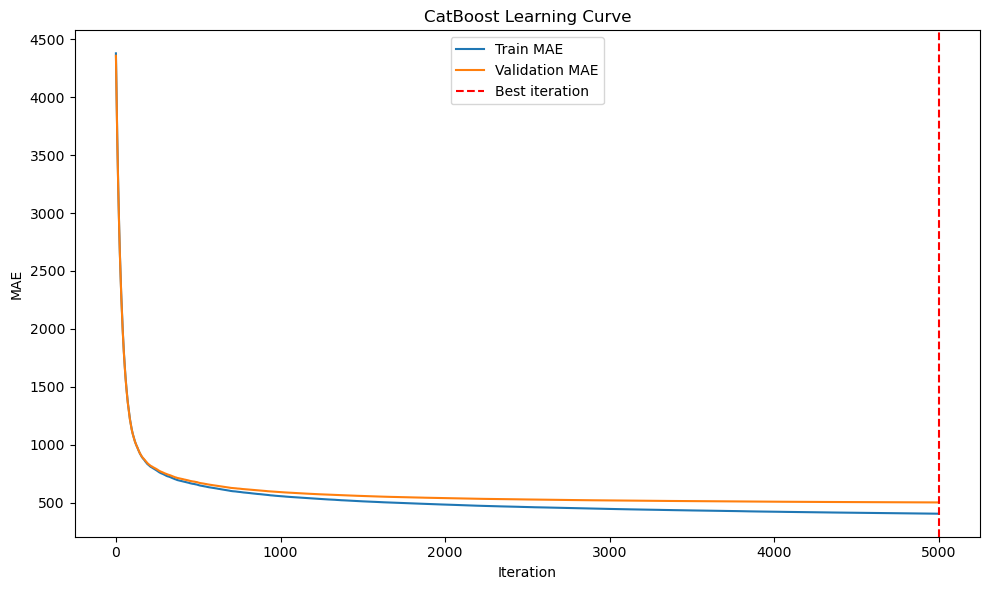

In [8]:
evals_result = cat_model.get_evals_result()
learn_mae = evals_result.get("learn", {}).get("MAE", [])
val_mae_curve = evals_result.get("validation", {}).get("MAE", [])

fig, ax = plt.subplots(figsize=(10, 6))
if learn_mae:
    ax.plot(learn_mae, label="Train MAE")
if val_mae_curve:
    ax.plot(val_mae_curve, label="Validation MAE")
    ax.axvline(best_iteration, color="red", linestyle="--", linewidth=1.5, label="Best iteration")

ax.set_title("CatBoost Learning Curve")
ax.set_xlabel("Iteration")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "catboost_learning_curve.png", bbox_inches="tight")
plt.show()

## 9. Feature Importance Top 30

Feature importance is computed by CatBoost on the validation pool. This helps identify which raw, engineered, categorical, and aggregation features drive predictions.

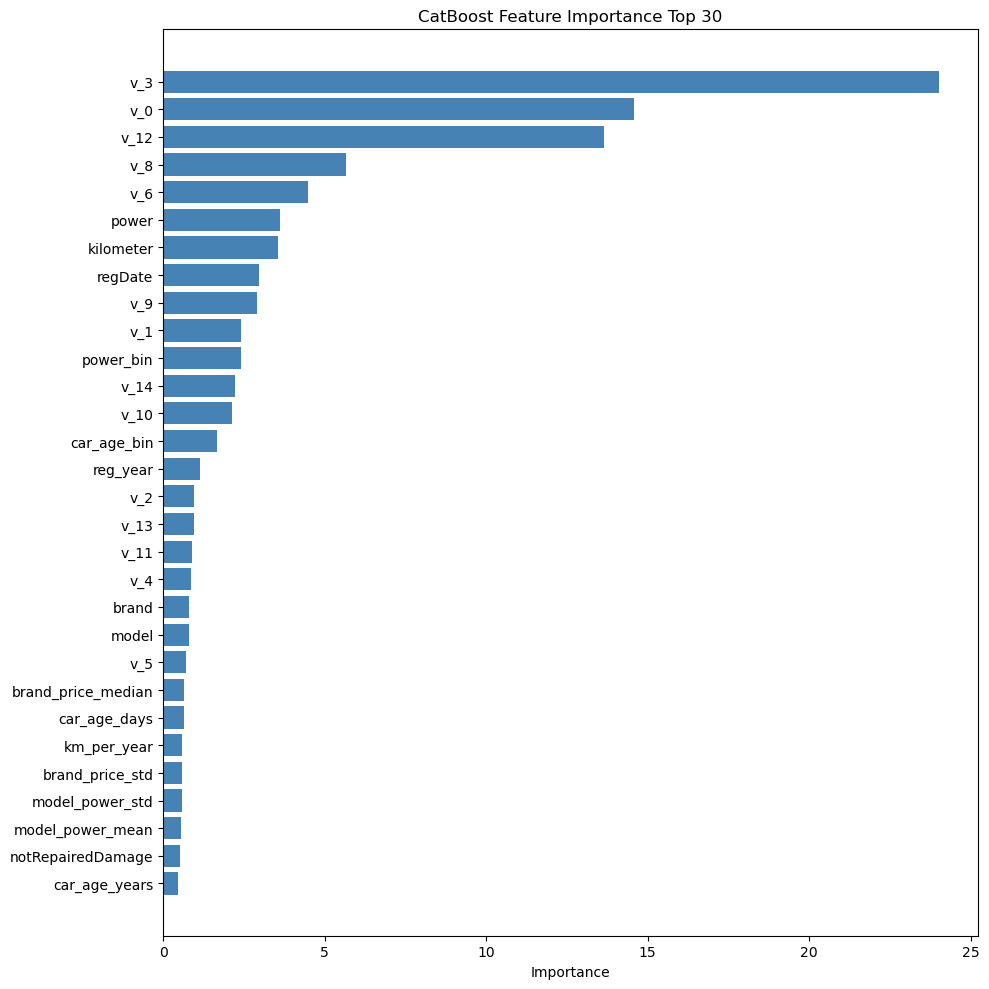

,feature,importance
17,v_3,24.019200
14,v_0,14.567637
26,v_12,13.658194
22,v_8,5.660063
20,v_6,4.489672
7,power,3.604661
8,kilometer,3.552812
1,regDate,2.963928
23,v_9,2.891329
15,v_1,2.406684


In [9]:
feature_importance = pd.DataFrame(
    {
        "feature": X_train_cb.columns,
        "importance": cat_model.get_feature_importance(val_pool),
    }
).sort_values("importance", ascending=False)

top_n = 30
fig, ax = plt.subplots(figsize=(10, 10))
plot_df = feature_importance.head(top_n).sort_values("importance")
ax.barh(plot_df["feature"], plot_df["importance"], color="steelblue")
ax.set_title(f"CatBoost Feature Importance Top {top_n}")
ax.set_xlabel("Importance")
plt.tight_layout()
fig.savefig(FIG_DIR / "catboost_feature_importance_top30.png", bbox_inches="tight")
plt.show()

feature_importance.head(top_n)

## 10. Save CatBoost Model

The model is saved in CatBoost native `.cbm` format.

In [10]:
cat_model.save_model(CATBOOST_MODEL_PATH)
print(f"Saved model: {CATBOOST_MODEL_PATH}")

Saved model: /Users/josephwang/Documents/2026 Job Search/2026 求职/demos/used-car-dynamic-pricing/models/catboost_model.cbm


## 11. Export Validation Predictions

Export validation predictions with residual and absolute error for downstream error analysis.

In [11]:
catboost_val_preds = pd.DataFrame(
    {
        "SaleID": id_val.values,
        "actual_price": y_val.values,
        "predicted_price": cat_val_pred,
        "residual": y_val.values - cat_val_pred,
        "abs_error": np.abs(y_val.values - cat_val_pred),
    }
)

catboost_val_preds.to_csv(CATBOOST_PRED_PATH, index=False)
print(f"Saved predictions: {CATBOOST_PRED_PATH}")
catboost_val_preds.head()

Saved predictions: /Users/josephwang/Documents/2026 Job Search/2026 求职/demos/used-car-dynamic-pricing/outputs/catboost_validation_predictions.csv


,SaleID,actual_price,predicted_price,residual,abs_error
0,59770,999,1008.471860,-9.471860,9.471860
1,21362,8500,8376.696000,123.304000,123.304000
2,127324,15500,15779.062021,-279.062021,279.062021
3,140509,10000,9967.346154,32.653846,32.653846
4,144297,2999,2941.443181,57.556819,57.556819


## 12. Compare with XGBoost Baseline

The XGBoost baseline predictions are loaded from `outputs/xgb_validation_predictions.csv`. Since both notebooks use the same split parameters, MAE is directly comparable.

In [12]:
comparison_rows = [
    {
        "model": "CatBoost",
        "validation_mae": cat_val_mae,
        "train_mae": cat_train_mae,
        "best_iteration": best_iteration,
    }
]

if XGB_PRED_PATH.exists():
    xgb_preds = pd.read_csv(XGB_PRED_PATH)
    xgb_val_mae = mean_absolute_error(xgb_preds["actual_price"], xgb_preds["predicted_price"])
    comparison_rows.append(
        {
            "model": "XGBoost",
            "validation_mae": xgb_val_mae,
            "train_mae": np.nan,
            "best_iteration": np.nan,
        }
    )
else:
    print(f"XGBoost prediction file not found: {XGB_PRED_PATH}")

comparison_df = pd.DataFrame(comparison_rows).sort_values("validation_mae")
comparison_df["mae_gap_vs_best"] = comparison_df["validation_mae"] - comparison_df["validation_mae"].min()
comparison_df

,model,validation_mae,train_mae,best_iteration,mae_gap_vs_best
0,CatBoost,501.669429,416.041942,4999.0,0.000000
1,XGBoost,514.231043,NaN,NaN,12.561614


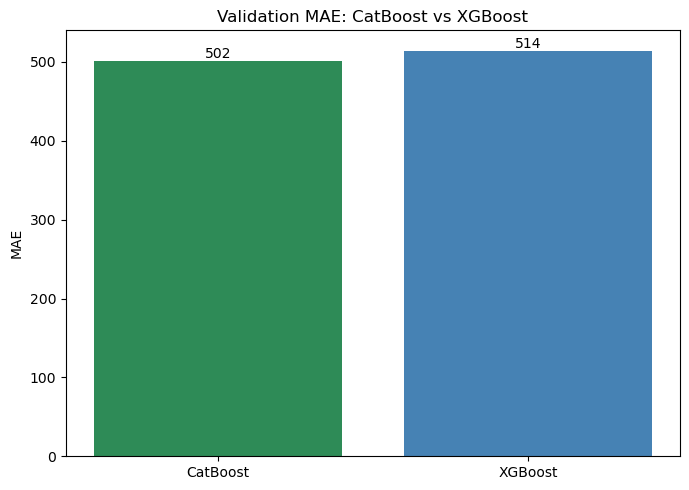

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(comparison_df["model"], comparison_df["validation_mae"], color=["seagreen" if m == "CatBoost" else "steelblue" for m in comparison_df["model"]])
ax.set_title("Validation MAE: CatBoost vs XGBoost")
ax.set_ylabel("MAE")
for i, row in comparison_df.reset_index(drop=True).iterrows():
    ax.text(i, row["validation_mae"], f"{row['validation_mae']:,.0f}", ha="center", va="bottom")
plt.tight_layout()
fig.savefig(FIG_DIR / "catboost_vs_xgboost_mae.png", bbox_inches="tight")
plt.show()

## 13. Summary

### Why CatBoost May Perform Better

CatBoost is designed for datasets with many categorical variables. It uses ordered boosting and built-in categorical encoding, which can reduce prediction shift and handle high-cardinality categories such as `model`, `name`, and `regionCode` more naturally than manual label encoding.

### Importance of Categorical Features

Used-car prices depend heavily on categorical business attributes: brand, model, body type, fuel type, gearbox, damage status, and region. Treating these as categorical signals allows the model to learn category-specific price levels instead of assuming arbitrary numeric order.

### Risk of Target Leakage

The processed dataset includes `brand_price_mean`, `brand_price_median`, `brand_price_std`, and `brand_price_max`. These features are derived from `price`, so they can leak target information if computed on the full training data before validation. For production-grade modeling, these should be rebuilt using out-of-fold aggregation or computed only from historical training folds.

### Overfitting Observations

Compare train MAE and validation MAE, plus the learning curve. A much lower train MAE than validation MAE indicates overfitting. If overfitting is strong, consider reducing depth, increasing regularization, removing leakage-prone target aggregation features, or using more conservative early stopping.